# IoT to IDS transfer learning results

Tested again zero-shot and few shot learning. Experiment configuration:
- Few shot samples per class: 1000
- Transformer training: 30 epochs with early stop
- LSTM training: 5 epochs with early stop
- CNN training: 40 epochs with early stop

The experiments tested the cases where network specific features exist in datasets, and when they are removed from datasets. Finally, the dataset was created by randomly sampling by equal amounts from all datasets, while preserving class balance (50% benign, 50% malicious samples)


## Loading the required Python packages for processing
Loading global functions and overall useful processing functions as well.

In [37]:
import pandas as pd
import os
import matplotlib.pyplot as plt

RESULTS_DIR = "../../results/reports"

transformer_fs_all_df = pd.read_csv(os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/iot_vs_ids/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv"))
lstm_fs_all_df = pd.read_csv(os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/iot_vs_ids/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv"))
cnn_fs_all_df = pd.read_csv(os.path.join(RESULTS_DIR, "cnn/few_shot/1000_samples/iot_vs_ids/with_network_specific_features/40_epochs_early_stop/results_cnn_TL_few_shot.csv"))

transformer_fs_removed_df = pd.read_csv(os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/iot_vs_ids/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv"))
lstm_fs_removed_df = pd.read_csv(os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/iot_vs_ids/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv"))
cnn_fs_removed_df = pd.read_csv(os.path.join(RESULTS_DIR, "cnn/few_shot/1000_samples/iot_vs_ids/separate_removed_features/40_epochs_early_stop/results_cnn_TL_removed_few_shot.csv"))

transformer_zs_all_df = pd.read_csv(os.path.join(RESULTS_DIR, "transformer/zero_shot/iot_vs_ids/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_zero_shot.csv"))
lstm_zs_all_df = pd.read_csv(os.path.join(RESULTS_DIR, "lstm/zero_shot/iot_vs_ids/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_zero_shot.csv"))
cnn_zs_all_df = pd.read_csv(os.path.join(RESULTS_DIR, "cnn/zero_shot/iot_vs_ids/with_network_specific_features/40_epochs_early_stop/results_cnn_TL_zero_shot.csv"))

transformer_zs_removed_df = pd.read_csv(os.path.join(RESULTS_DIR, "transformer/zero_shot/iot_vs_ids/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_zero_shot.csv"))
lstm_zs_removed_df = pd.read_csv(os.path.join(RESULTS_DIR, "lstm/zero_shot/iot_vs_ids/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_zero_shot.csv"))
cnn_zs_removed_df = pd.read_csv(os.path.join(RESULTS_DIR, "cnn/zero_shot/iot_vs_ids/separate_removed_features/40_epochs_early_stop/results_cnn_TL_removed_zero_shot.csv"))

def create_metrics_df(transformer_df, lstm_df, cnn_df) -> pd.DataFrame:
    transformer_iot_ids = transformer_df.loc[transformer_df["Fold #"] == 1]
    transformer_ids_iot = transformer_df.loc[transformer_df["Fold #"] == 2]
    lstm_iot_ids = lstm_df.loc[lstm_df["Fold #"] == 1]
    lstm_ids_iot = lstm_df.loc[lstm_df["Fold #"] == 2]
    cnn_iot_ids = cnn_df.loc[cnn_df["Fold #"] == 1]
    cnn_ids_iot = cnn_df.loc[cnn_df["Fold #"] == 2]

    data_no_mean = [
        [transformer_iot_ids["Accuracy"].mean(), lstm_iot_ids["Accuracy"].mean(), cnn_iot_ids["Accuracy"].mean()],
        [transformer_ids_iot["Accuracy"].mean(), lstm_ids_iot["Accuracy"].mean(), cnn_ids_iot["Accuracy"].mean()]
    ]

    metrics_df = pd.DataFrame(data_no_mean, columns=["Transformer", "LSTM", "CNN"], index=["IoT to IDS", "IDS to IoT"])
    return metrics_df

## Summary plot

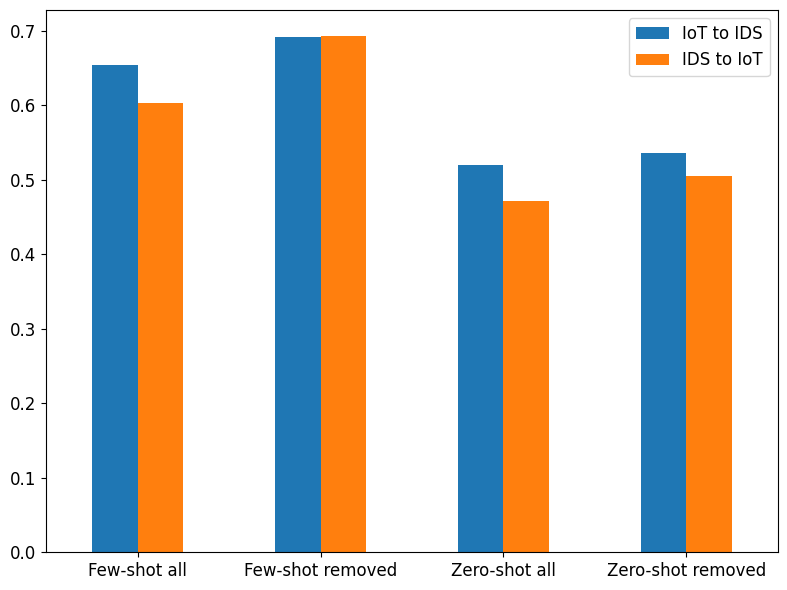

In [42]:
metrics_fs_all_df = create_metrics_df(transformer_fs_all_df, lstm_fs_all_df, cnn_fs_all_df)
metrics_fs_removed_df = create_metrics_df(transformer_fs_removed_df, lstm_fs_removed_df, cnn_fs_removed_df)
metrics_zs_all_df = create_metrics_df(transformer_zs_all_df, lstm_zs_all_df, cnn_zs_all_df)
metrics_zs_removed_df = create_metrics_df(transformer_zs_removed_df, lstm_zs_removed_df, cnn_zs_removed_df)

merged_metrics_df = pd.concat([metrics_fs_all_df.mean(axis=1), 
                               metrics_fs_removed_df.mean(axis=1), 
                               metrics_zs_all_df.mean(axis=1), 
                               metrics_zs_removed_df.mean(axis=1)], axis=1)
merged_metrics_df = merged_metrics_df.set_axis(["Few-shot all", "Few-shot removed", "Zero-shot all", "Zero-shot removed"], axis=1)
ax = merged_metrics_df.T.plot(kind='bar', rot=0, figsize=(8,6), fontsize=12)
ax.legend(loc='best', prop={'size': 12})
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("cross_domain_tl_summary.pdf")

## Few-shot transfer learning
### With network specific features

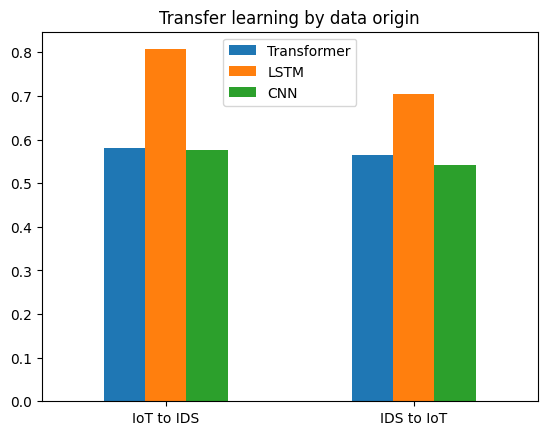

In [3]:
ax = metrics_fs_all_df.plot(kind='bar', rot=0)
ax.set_title("Transfer learning by data origin")
fig = ax.get_figure()
fig.savefig("iot_vs_ids_few_shot_nomean.pdf")

### Without network specific features

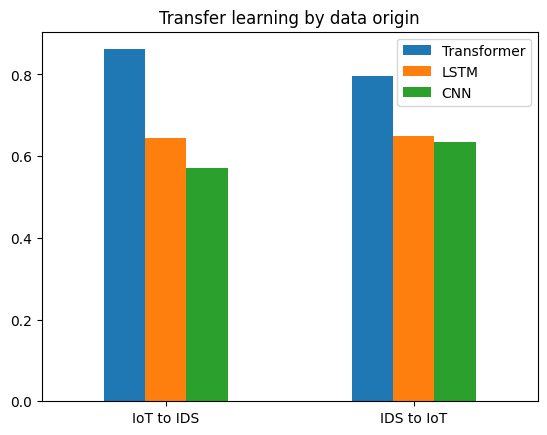

In [4]:
ax = metrics_fs_removed_df.plot(kind='bar', rot=0)
ax.set_title("Transfer learning by data origin")
fig = ax.get_figure()
fig.savefig("iot_vs_ids_few_shot_removed_nomean.pdf")

## Zero shot transfer learning
### With network specific features

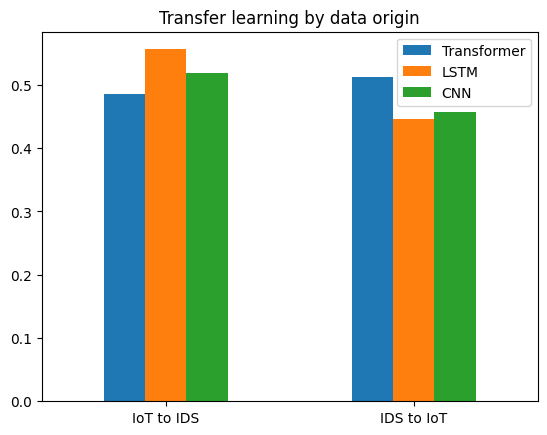

In [5]:
ax = metrics_zs_all_df.plot(kind='bar', rot=0)
ax.set_title("Transfer learning by data origin")
fig = ax.get_figure()
fig.savefig("iot_vs_ids_zero_shot.pdf")

### Without network specific features

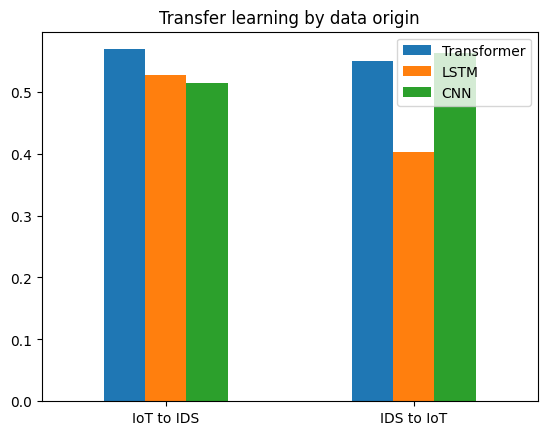

In [6]:
ax = metrics_zs_removed_df.plot(kind='bar', rot=0)
ax.set_title("Transfer learning by data origin")
fig = ax.get_figure()
fig.savefig("iot_vs_ids_zero_shot_removed.pdf")